In [43]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import os
from mypackages.eRDF import *
from tqdm import tqdm 
from mypackages.edp_processing import peak_calibration

from matplotlib import rcParams, cycler
from matplotlib.ticker import AutoMinorLocator

from mypackages.plot_style import set_plot_style

set_plot_style()

The calculated calibration factor ds: 0.00743649587727647


<function matplotlib.pyplot.show(close=None, block=None)>

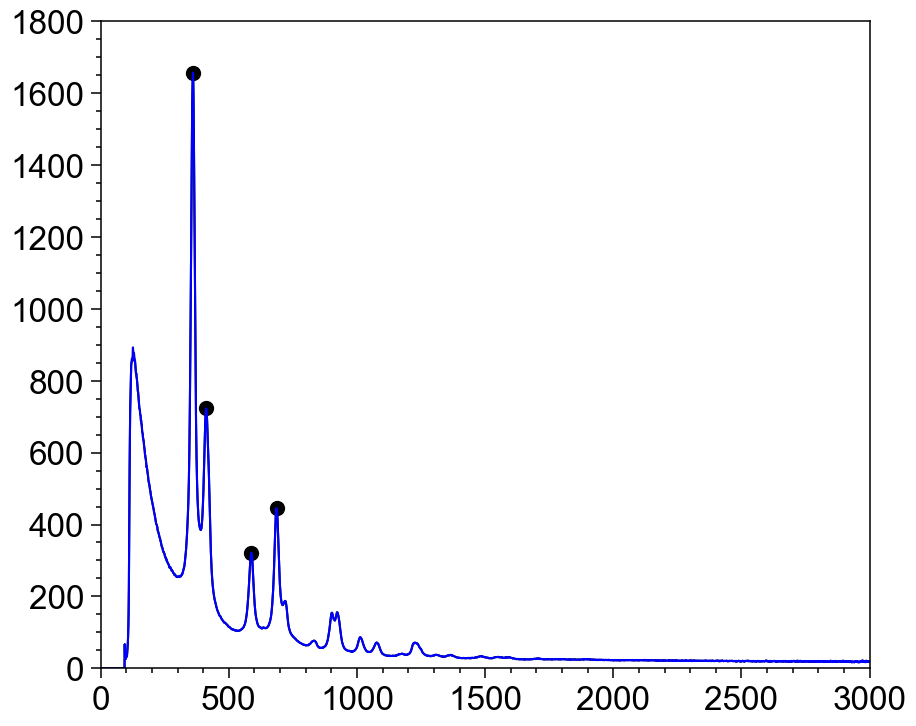

In [2]:
#gold peak calibration
from scipy.signal import find_peaks

path = r"../../../data\processed\ePDF\Au"

#end_name = 'Au_end.csv'
start_name = 'Au_start.csv'

df1 = pd.read_csv(os.path.join(path, start_name), header = None)
#df2 = pd.read_csv(os.path.join(path, end_name), header = None)

data_start = df1[0].values
#data_end = df2[0].values

peaks_start, _ = find_peaks(data_start, distance = 40, height=300)
#peaks_end, _ = find_peaks(data_end, distance = 40, height=500)



calibration = peak_calibration(pixel_positions = peaks_start[3:7])
#calibration_end = peak_calibration(pixel_positions = peaks_end[1:5])

#calibration = (calibration_start +calibration_end)/2

#peaks_end, _ = find_peaks(data_end, distance = 1, height=500)

plt.plot(data_start)
plt.plot(df1[0].values)
plt.scatter(peaks_start[3:7], data_start[peaks_start[3:7]])
plt.show

The calculated calibration factor ds: 0.012841416172453794


<function matplotlib.pyplot.show(close=None, block=None)>

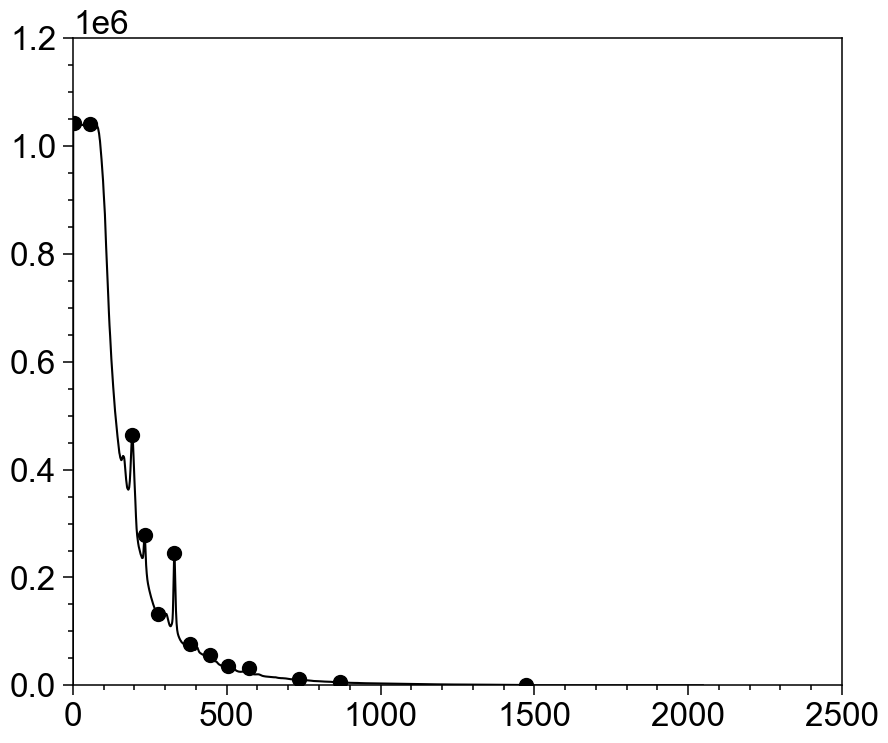

In [105]:
#gold peak calibration
from scipy.signal import find_peaks



start_name = r"C:\Users\seccolev\data_processing\data\processed\ePDF\Fe3O4\20250703\Fe3O4-summed-1000-center-350.csv"

df1 = pd.read_csv(start_name, header = None)

start = 0
data = df1[0].values[start:]

peaks_start, _ = find_peaks(data, distance = 40, height=200, prominence=100)

calibrate = True
sub = True

if calibrate:
    if sub:
        indices = [2,3,5] 
        subset = [peaks_start[i] for i in indices]
        subset = np.array(subset)
        calibration = peak_calibration(pixel_positions = subset+start, standard=None, peaks=[2.53224,2.09963, 1.484659])
    else:
        calibration = peak_calibration(pixel_positions = peaks_start+start, standard=None, peaks=[2.53224,2.09963, 1.484659])


plt.plot(data)
plt.scatter(peaks_start, data[peaks_start])
plt.show

In [95]:
peaks_start

array([  98,  163,  194,  233,  284,  330,  381,  446,  503,  571,  602,
        724,  871, 1514, 1620, 1680, 1712])

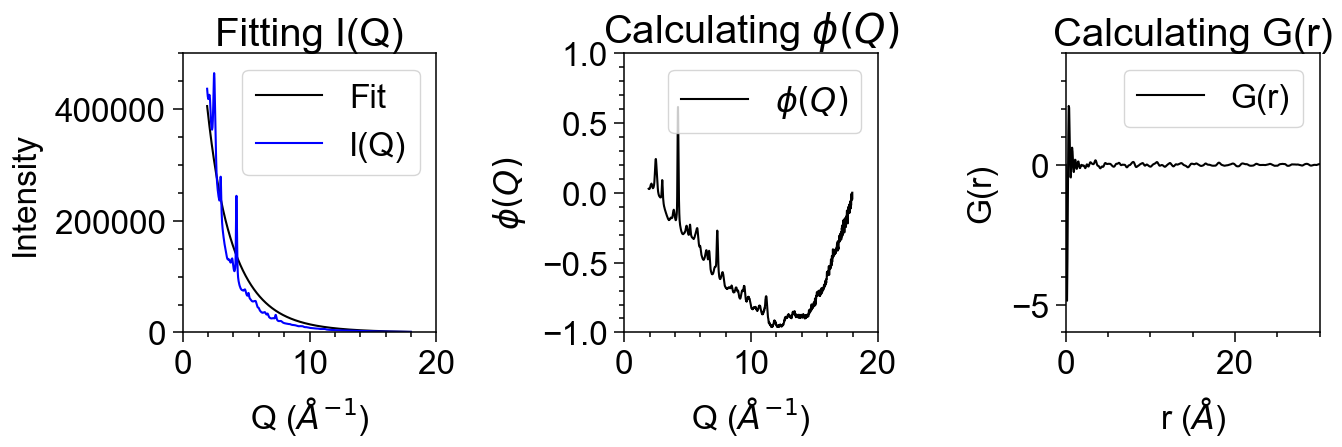

np.float64(17.97798264143531)

In [106]:
df1 = pd.read_csv(start_name, header = None)

start = 0
data = df1[0].values[start:]

ds= calibration
ds = (ds)/(2*math.pi) #AuNPs

CdSe =  {1: [30, 1], 2: [8, 1],}
Magnetite = {1: [28, 2], 2: [8, 3],}

start =150
qmax =18 # For example
end = int(qmax / (ds * 2 * math.pi))

end = min(end, data.shape[-1])

dp1 = DataProcessor(data = data, q0 = 0, lobato_path= None, start= start, end = end, ds = ds, Elements = Magnetite, region = 0)
 

iq = dp1.iq
sq, fq = dp1.SQ_PhiQ(iq, 0)
r, Gr = dp1.Gr(fq, rmax=80, dr=0.05)


dp1.plot_results(fq, r, Gr0=Gr)
dp1.q.max()


In [107]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt


# Normalize the data
norm_data = data[start:end] / (dp1.N * dp1.fq_sq)
norm_data = norm_data * dp1.q

degree = 8
# Fit the polynomial
coefficients = np.polyfit(dp1.q, norm_data, degree)
polynomial = np.poly1d(coefficients)

# Generate x values for plotting the polynomial fit
x_fit = np.linspace(dp1.q.min(), dp1.q.max(), len(norm_data))
y_fit = polynomial(x_fit)

# Calculate _fq_poly and apply Butterworth lowpass filter
fq_poly = norm_data - y_fit


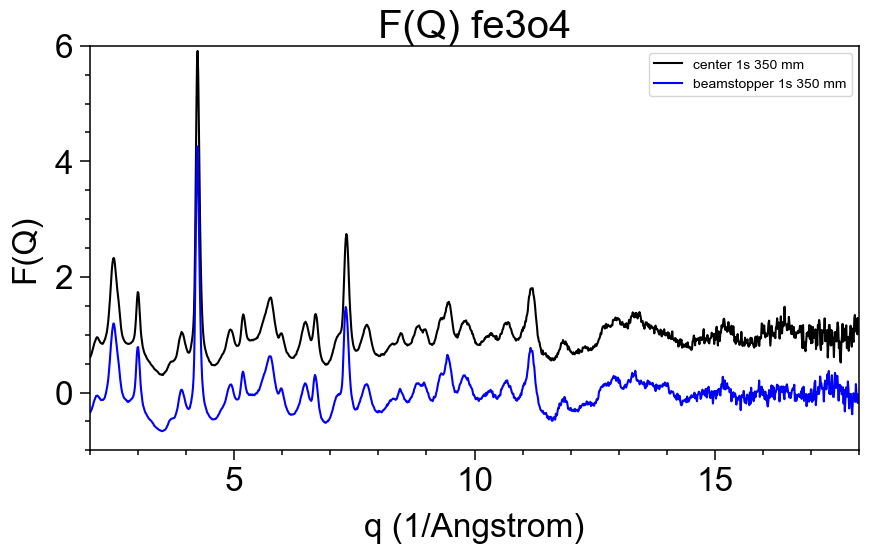

In [114]:
plt.figure(figsize=(10, 5))


plt.plot(dp1.q, fq_poly+1, label='center 1s 350 mm')
plt.plot(qbq, fqbs, label='beamstopper 1s 350 mm')
# plt.bar(br, i*15, width=0.05, color="red", label = "COD 1513304")
plt.xlim(2, 18)
plt.ylim(-1,6)
plt.xlabel('q (1/Angstrom)')
plt.ylabel('F(Q)')
plt.title('F(Q) fe3o4')
plt.legend(fontsize=10)
plt.show()

In [104]:
qbq, fqbs = dp1.q, fq_poly

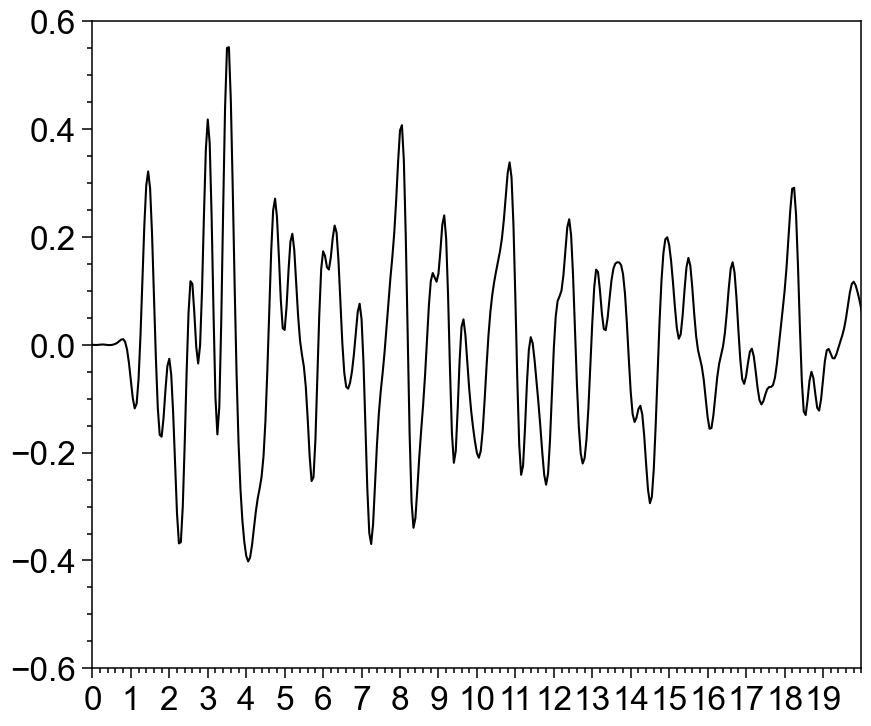

In [26]:

r, Gr = dp1.Gr(fq_poly, rmax=80, dr=0.05)

plt.plot(r, Gr)
plt.xlim(0,20)
plt.xticks(np.arange(0,20))
plt.show()

In [7]:
qbc, fqbc = dp1.q, fq_poly

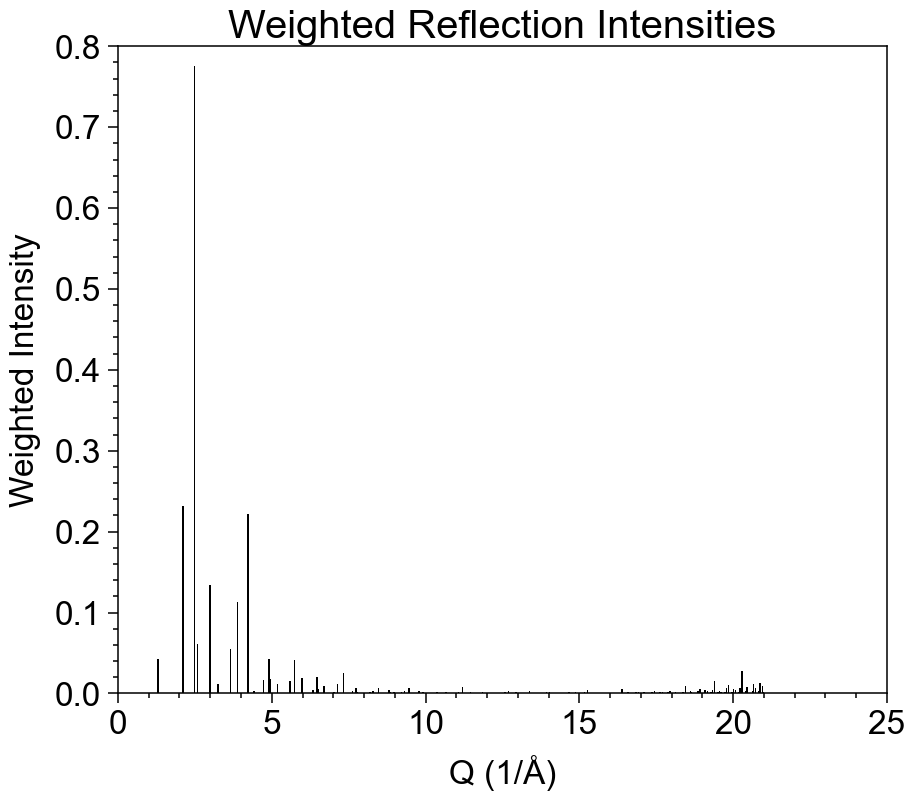

In [73]:
df = pd.read_csv(r"\\fshomes\seccolev$\Downloads\Fe3O4_1513304.txt", sep=r"[\t ]+", engine="python")

# Reflection intensities
i = df["I"].values / 100  # normalized

# Q from d-spacing
br = 2 * np.pi / df["d(Å)"].values  # same as Q

# Interpolate fq_sq at br points
# fq_sq should be shape (N,), and q should match that length
fq_sq_interp = np.interp(br, dp1.q, dp1.fq_sq)

# Multiply intensity by fq_sq
weighted_i = i * fq_sq_interp

# Plot
plt.bar(br, weighted_i, width=0.05)
plt.xlabel("Q (1/Å)")
plt.ylabel("Weighted Intensity")
plt.title("Weighted Reflection Intensities")
plt.show()

In [ ]:
import Dans_Diffraction as dif
import numpy as np
import pandas as pd

xtl = dif.Crystal(r"E:\data_processing\data\crystallographic_db\Fe3O4_1513304.cif")

xtl.Scatter.setup_scatter(scattering_type='electron', energy_kev=200, min_twotheta=0.1, max_twotheta=10)

# Get full reflection list
reflections = xtl.Scatter.get_hkl()
transmission = xtl.hkl_transmission(reflections)
q_mag = xtl.Cell.Qmag(reflections)
F2 = xtl.Scatter.electron(reflections)

# Set desired Q max in Å⁻¹
Q_max = 10.0

# Filter based on Q
mask = q_mag <= Q_max
hkl_filtered = reflections[mask]
q_filtered = q_mag[mask]
f2_filtered = F2[mask]

# Convert to DataFrame
df = pd.DataFrame(hkl_filtered, columns=["h", "k", "l"])
df["Q"] = q_filtered
df["F2"] = f2_filtered

df_nonzero = df[df["F2"] > 1e-5]

# Optional: reset index
df_nonzero = df_nonzero.reset_index(drop=True)

df_unique = df.groupby(df_nonzero["Q"].round(5), as_index=False).apply(lambda g: g.loc[g["F2"].idxmax()])
df_unique.reset_index(drop=True, inplace=True)

df_unique

Scatter(Fe3O4_1513304 with 3 atomic positions, 192 symmetries)
       Type: electron
     Energy: 200 keV
 Wavelength: 0.061992214464378345 A
 ---Settings---
      Powder units: tth
    Isotropic ADPs: True
  Specular Direction (reflection): ( 0, 0, 1)
Parallel Direction (transmission): ( 0, 0, 1)
      theta offset: 0.0
         min theta: -180.0
         max theta: 180.0
      min twotheta: 0.1
      max twotheta: 10
 ---X-Ray Settings---
 Waasmaier scattering factor: False
 ---Neutron Settings---
 Sears (ITC) scattering lengths: False
 ---Magnetic Settings---
   Mag. scattering: True
  Mag. form factor: True
         Polarised: False
      Polarisation: sp
       Pol. vector: (0,1,0)
 ---Resonant Settings---
   Azimuthal angle: 0
    Azimuthal ref.: (1,0,0)
               flm: (0,1,0)
  use e1e1 approx.: True



TypeError: Scattering.hkl_transmission() missing 1 required positional argument: 'HKL'

(-1.0, 1.0)

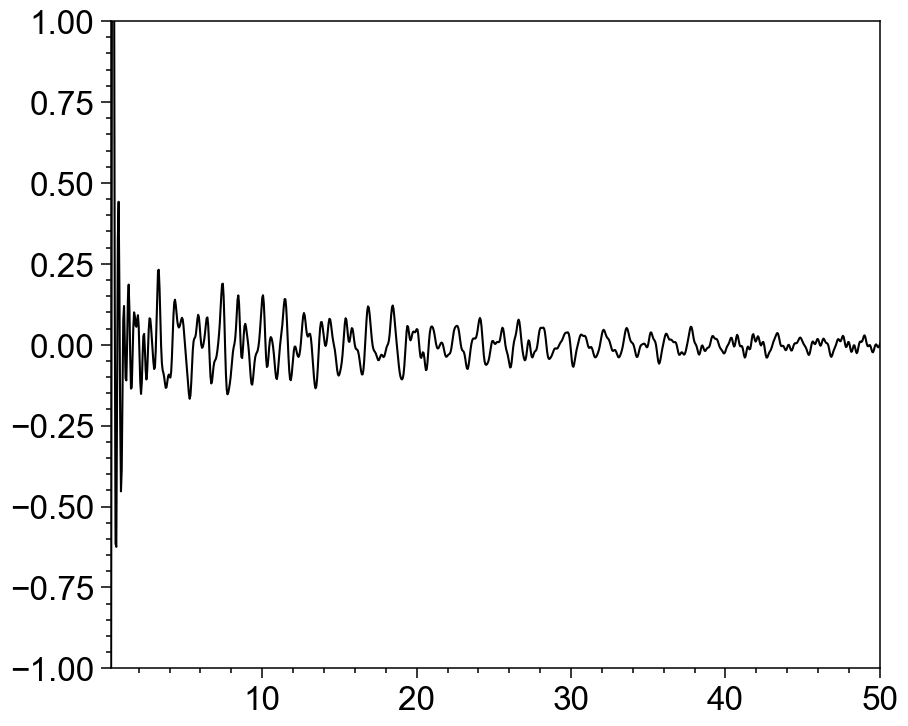

In [293]:
plt.plot(r, Gr, label='Lorch corrected')
plt.xlim(0.2, 50)
plt.ylim(-1, 1)

In [3]:
from mypackages.eRDF import read_discus_fit_file

df = read_discus_fit_file(r"C:\Users\seccolev\DISCUS\CdSe_DISCUS\P5\P5Debye_St_fault\REF_KID.fq")
df

,r,gr
0,1.11000,-1.050955
1,1.11757,-1.050775
2,1.12514,-1.050887
3,1.13271,-1.052348
4,1.14028,-1.054769
...,...,...
2085,16.89345,0.000017
2086,16.90102,-0.000044
2087,16.90859,-0.000098
2088,16.91616,-0.000154


(0.0, 20.0)

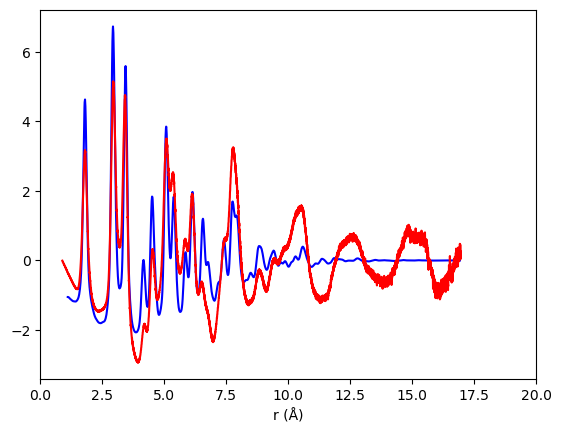

In [8]:
from mypackages.eRDF import read_discus_fit_file
import pandas as pd

df = read_discus_fit_file(r"C:\Users\seccolev\DISCUS\CdSe_DISCUS\P5\P5Debye_St_fault\REF_KID.fq")
df_p5 = pd.read_csv(r"C:\Users\seccolev\data_processing\data\processed\ePDF\CdSe\fq_pca_CdSe_P5.csv", sep="\t")

q, fq = df["r"].values, df["gr"].values
q_p5, fq_p5 = df_p5["q"].values, df_p5["sq"].values


df_p5

import matplotlib.pyplot as plt

plt.plot(q, fq, label='CdSe', color='blue')
plt.plot(q_p5, fq_p5, label='CdSe P5', color='red')
plt.xlabel('r (Å)') 
plt.xlim(0, 20)

In [7]:
import pandas as pd
from mypackages.eRDF import read_discus_fit_file

df_p5 = pd.read_csv(r"C:\Users\seccolev\data_processing\data\processed\ePDF\CdSe\fq_pca_CdSe_P5.csv", sep="\t")

#q, fq = df["r"].values, df["gr"].values
q_p5, fq_p5 = df_p5["q"].values, df_p5["sq"].values


df_p5

,q,sq
0,0.891,-0.005830
1,0.892,-0.008277
2,0.893,-0.010734
3,0.894,-0.013199
4,0.895,-0.015666
...,...,...
16054,16.945,0.036207
16055,16.946,0.208985
16056,16.947,0.203576
16057,16.948,0.221207
